In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision


# ===============================
# Encoder: ResNet50 (sin FC)
# ===============================
class ResNetEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        backbone = torchvision.models.resnet50(weights="IMAGENET1K_V1" if pretrained else None)
        
        # Tomamos capas hasta layer4
        self.initial = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        
    def forward(self, x):
        x0 = self.initial(x)     # 64 channels
        x1 = self.layer1(x0)     # 256
        x2 = self.layer2(x1)     # 512
        x3 = self.layer3(x2)     # 1024
        x4 = self.layer4(x3)     # 2048
        
        return x0, x1, x2, x3, x4

In [6]:
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x, skip):
        
        # Upsample x al tamaño del skip
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        
        return x

In [7]:
class SegmentationDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.up1 = UpBlock(2048, 1024, 512)  # 7→14
        self.up2 = UpBlock(512, 512, 256)    # 14→28
        self.up3 = UpBlock(256, 256, 128)    # 28→56
        self.up4 = UpBlock(128, 64, 64)      # 56→56
        
        self.final_up = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1)
        )
    
    def forward(self, x0, x1, x2, x3, x4):
        
        d1 = self.up1(x4, x3)
        d2 = self.up2(d1, x2)
        d3 = self.up3(d2, x1)
        d4 = self.up4(d3, x0)
        
        # Último upsample para volver a 224x224
        out = F.interpolate(d4, scale_factor=4, mode='bilinear', align_corners=False)
        
        out = self.final_up(out)
        out = torch.sigmoid(out)
        
        return out

In [3]:
class ClassificationHead(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        
        self.fc = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [9]:
class MultiTaskBreastNet(nn.Module):
    def __init__(self, pretrained=True, num_classes=2):
        super().__init__()
        
        self.encoder = ResNetEncoder(pretrained)
        self.decoder = SegmentationDecoder()
        self.classifier = ClassificationHead(num_classes)
    
    def forward(self, x):
        x0, x1, x2, x3, x4 = self.encoder(x)
        
        # Segmentación
        mask_pred = self.decoder(x0, x1, x2, x3, x4)
        
        # Clasificación
        class_logits = self.classifier(x4)
        
        return mask_pred, class_logits

In [10]:
model = MultiTaskBreastNet(pretrained=True, num_classes=2)

dummy = torch.randn(2, 3, 224, 224)

mask_out, class_out = model(dummy)

print(mask_out.shape)
print(class_out.shape)

torch.Size([2, 1, 224, 224])
torch.Size([2, 2])


In [12]:
import os
import cv2
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset


class CBISDataset(Dataset):
    def __init__(self, xlsx_file, root_dir, transform=None):
        self.data = pd.read_excel(xlsx_file)
        self.root_dir = root_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def apply_clahe(self, img):
        img_uint8 = (img * 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img_clahe = clahe.apply(img_uint8)
        return img_clahe / 255.0
    
    def preprocess_image(self, img_path):
        img = cv2.imread(os.path.join(self.root_dir, img_path), cv2.IMREAD_GRAYSCALE)
        img = img.astype(np.float32) / 255.0
        
        img = self.apply_clahe(img)
        
        img = cv2.resize(img, (224,224))
        
        img = np.stack([img, img, img], axis=0)  # 3 canales
        
        return torch.tensor(img, dtype=torch.float32)
    
    def preprocess_mask(self, mask_path):
        mask = cv2.imread(os.path.join(self.root_dir, mask_path), cv2.IMREAD_GRAYSCALE)
        mask = mask.astype(np.float32) / 255.0
        
        mask = cv2.resize(mask, (224,224))
        mask = np.expand_dims(mask, axis=0)
        
        return torch.tensor(mask, dtype=torch.float32)
    
    def get_label(self, pathology):
        return 1 if pathology == "MALIGNANT" else 0
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        image = self.preprocess_image(row["full_mammogram_img_path"])
        mask = self.preprocess_mask(row["roi_image_img_path"])
        label = torch.tensor(self.get_label(row["pathology"]), dtype=torch.long)
        
        return image, mask, label

In [ ]:
dataset = CBISDataset(
    xlsx_file="mass_case_train.xlsx",
    root_dir="..",
)

img, mask, label = dataset[0]

print(img.shape)   # [3,224,224]
print(mask.shape)  # [1,224,224]
print(label)       # 0 o 1

torch.Size([3, 224, 224])
torch.Size([1, 224, 224])
tensor(1)


In [20]:
import torch.nn as nn

bce = nn.BCELoss()
ce = nn.CrossEntropyLoss()

def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def total_loss(mask_pred, mask_gt, class_logits, class_gt,
               alpha=1.0, beta=1.0):
    
    seg_loss = bce(mask_pred, mask_gt) + dice_loss(mask_pred, mask_gt)
    cls_loss = ce(class_logits, class_gt)
    
    return alpha * cls_loss + beta * seg_loss

In [24]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

In [28]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = MultiTaskBreastNet(pretrained=True, num_classes=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 5

for epoch in range(num_epochs):
    
    model.train()
    
    running_total = 0.0
    running_seg = 0.0
    running_cls = 0.0
    
    for images, masks, labels in train_loader:
        
        images = images.to(device)
        masks = masks.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        mask_pred, class_logits = model(images)
        
        seg_loss = bce(mask_pred, masks) + dice_loss(mask_pred, masks)
        cls_loss = ce(class_logits, labels)
        
        loss = seg_loss + cls_loss
        
        loss.backward()
        optimizer.step()
        
        running_total += loss.item()
        running_seg += seg_loss.item()
        running_cls += cls_loss.item()
    
    print(f"\nEpoch {epoch+1}")
    print(f"  Total Loss: {running_total/len(train_loader):.4f}")
    print(f"  Seg Loss  : {running_seg/len(train_loader):.4f}")
    print(f"  Cls Loss  : {running_cls/len(train_loader):.4f}")


Epoch 1
  Total Loss: 1.6380
  Seg Loss  : 0.9471
  Cls Loss  : 0.6909

Epoch 2
  Total Loss: 1.3828
  Seg Loss  : 0.7419
  Cls Loss  : 0.6409

Epoch 3
  Total Loss: 1.2975
  Seg Loss  : 0.7110
  Cls Loss  : 0.5865

Epoch 4
  Total Loss: 1.2235
  Seg Loss  : 0.6877
  Cls Loss  : 0.5358

Epoch 5
  Total Loss: 1.0593
  Seg Loss  : 0.5824
  Cls Loss  : 0.4769


In [29]:
model.eval()

img, mask_gt, label = dataset[0]

with torch.no_grad():
    img_input = img.unsqueeze(0).to(device)
    mask_pred, cls_logits = model(img_input)

mask_pred = mask_pred.squeeze().cpu().numpy()
mask_gt = mask_gt.squeeze().numpy()
img_np = img.permute(1,2,0).cpu().numpy()

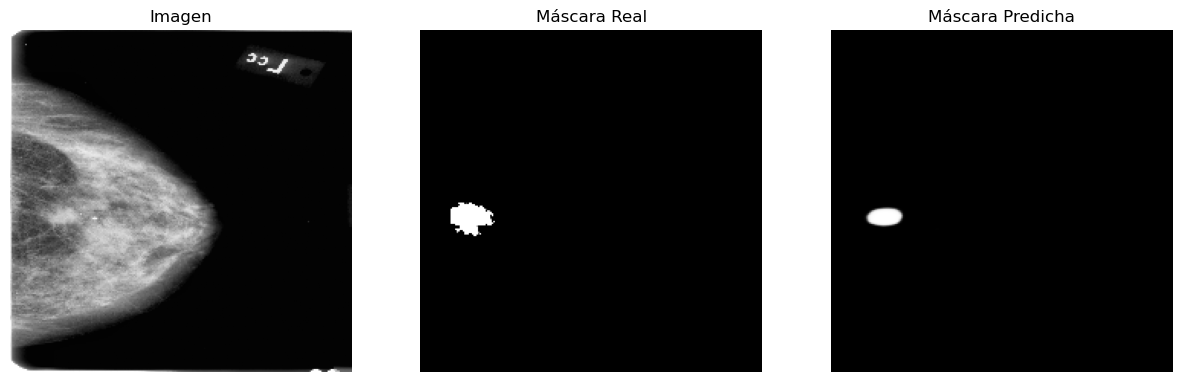

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Imagen")
plt.imshow(img_np)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Máscara Real")
plt.imshow(mask_gt, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Máscara Predicha")
plt.imshow(mask_pred, cmap="gray")
plt.axis("off")

plt.show()

In [32]:
#Métricas de segmentación
def dice_score(pred, target, threshold=0.5, smooth=1e-6):
    pred = (pred > threshold).float()
    
    pred = pred.view(-1)
    target = target.view(-1)
    
    intersection = (pred * target).sum()
    
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def iou_score(pred, target, threshold=0.5, smooth=1e-6):
    pred = (pred > threshold).float()
    
    pred = pred.view(-1)
    target = target.view(-1)
    
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    
    return (intersection + smooth) / (union + smooth)

In [34]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

In [ ]:
all_preds = []
all_labels = []
dice_list = []
iou_list = []

model.eval()

with torch.no_grad():
    for images, masks, labels in val_loader:
        
        images = images.to(device)
        masks = masks.to(device)
        labels = labels.to(device)
        
        mask_pred, class_logits = model(images)
        
        preds = torch.argmax(class_logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        dice_list.append(dice_score(mask_pred, masks).item())
        iou_list.append(iou_score(mask_pred, masks).item())

acc = accuracy_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)  # maligno como positivo
cm = confusion_matrix(all_labels, all_preds)

print("Accuracy:", acc)
print("Recall (Sensitivity):", recall)
print("Dice:", sum(dice_list)/len(dice_list))
print("IoU:", sum(iou_list)/len(iou_list))
print("Confusion Matrix:\n", cm)